In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

data = {
    'StudentID': range(1, 101),
    'Age': np.random.randint(16, 20, 100),
    'Gender': np.random.choice(['Male', 'Female'], 100),
    'StudyHours': np.round(np.random.uniform(0.5, 6, 100), 1),
    'Attendance': np.random.randint(50, 100, 100),
    'MathScore': np.random.randint(30, 100, 100),
    'EnglishScore': np.random.randint(30, 100, 100),
    'ScienceScore': np.random.randint(30, 100, 100),
}

df = pd.DataFrame(data)
df['AverageScore'] = df[['MathScore','EnglishScore','ScienceScore']].mean(axis=1).round(1)
df['PassFail'] = df['AverageScore'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

# Intentionally add 3 missing values to simulate real data
df.loc[[7, 23, 61], 'StudyHours'] = np.nan

print("Dataset created successfully!")
print(df.head(10))

Dataset created successfully!
   StudentID  Age  Gender  StudyHours  Attendance  MathScore  EnglishScore  \
0          1   18    Male         0.7          73         62            45   
1          2   19  Female         4.0          60         38            53   
2          3   16  Female         2.2          98         72            31   
3          4   18  Female         3.3          57         77            61   
4          5   18  Female         5.5          85         68            53   
5          6   19  Female         1.9          87         71            41   
6          7   16  Female         2.8          89         55            79   
7          8   16  Female         NaN          69         79            64   
8          9   18  Female         1.8          84         54            62   
9         10   17    Male         0.9          97         53            62   

   ScienceScore  AverageScore PassFail  
0            33          46.7     Fail  
1            65          52.0

In [3]:
# ================================================
# STEP 1: MEANINGFUL QUESTIONS BEFORE ANALYSIS
# ================================================

questions = """
Before we analyze, here are our key questions:

1. Do students who study more hours tend to score higher?
2. Is attendance linked to better performance?
3. What is the pass/fail rate in this class?
4. Are there differences in scores between male and female students?
5. Are there any missing values or data problems?
"""

print(questions)


Before we analyze, here are our key questions:

1. Do students who study more hours tend to score higher?
2. Is attendance linked to better performance?
3. What is the pass/fail rate in this class?
4. Are there differences in scores between male and female students?
5. Are there any missing values or data problems?



In [4]:
# ================================================
# STEP 2: EXPLORE DATA STRUCTURE
# ================================================

print("=== SHAPE (rows, columns) ===")
print(df.shape)

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

=== SHAPE (rows, columns) ===
(100, 10)

=== COLUMN NAMES ===
['StudentID', 'Age', 'Gender', 'StudyHours', 'Attendance', 'MathScore', 'EnglishScore', 'ScienceScore', 'AverageScore', 'PassFail']

=== DATA TYPES ===
StudentID         int64
Age               int64
Gender           object
StudyHours      float64
Attendance        int64
MathScore         int64
EnglishScore      int64
ScienceScore      int64
AverageScore    float64
PassFail         object
dtype: object

=== FIRST 5 ROWS ===
   StudentID  Age  Gender  StudyHours  Attendance  MathScore  EnglishScore  \
0          1   18    Male         0.7          73         62            45   
1          2   19  Female         4.0          60         38            53   
2          3   16  Female         2.2          98         72            31   
3          4   18  Female         3.3          57         77            61   
4          5   18  Female         5.5          85         68            53   

   ScienceScore  AverageScore PassFail  


/tmp/ipykernel_16048/3405526225.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='AverageScore', data=df, ax=axes[1, 1], palette='pastel')


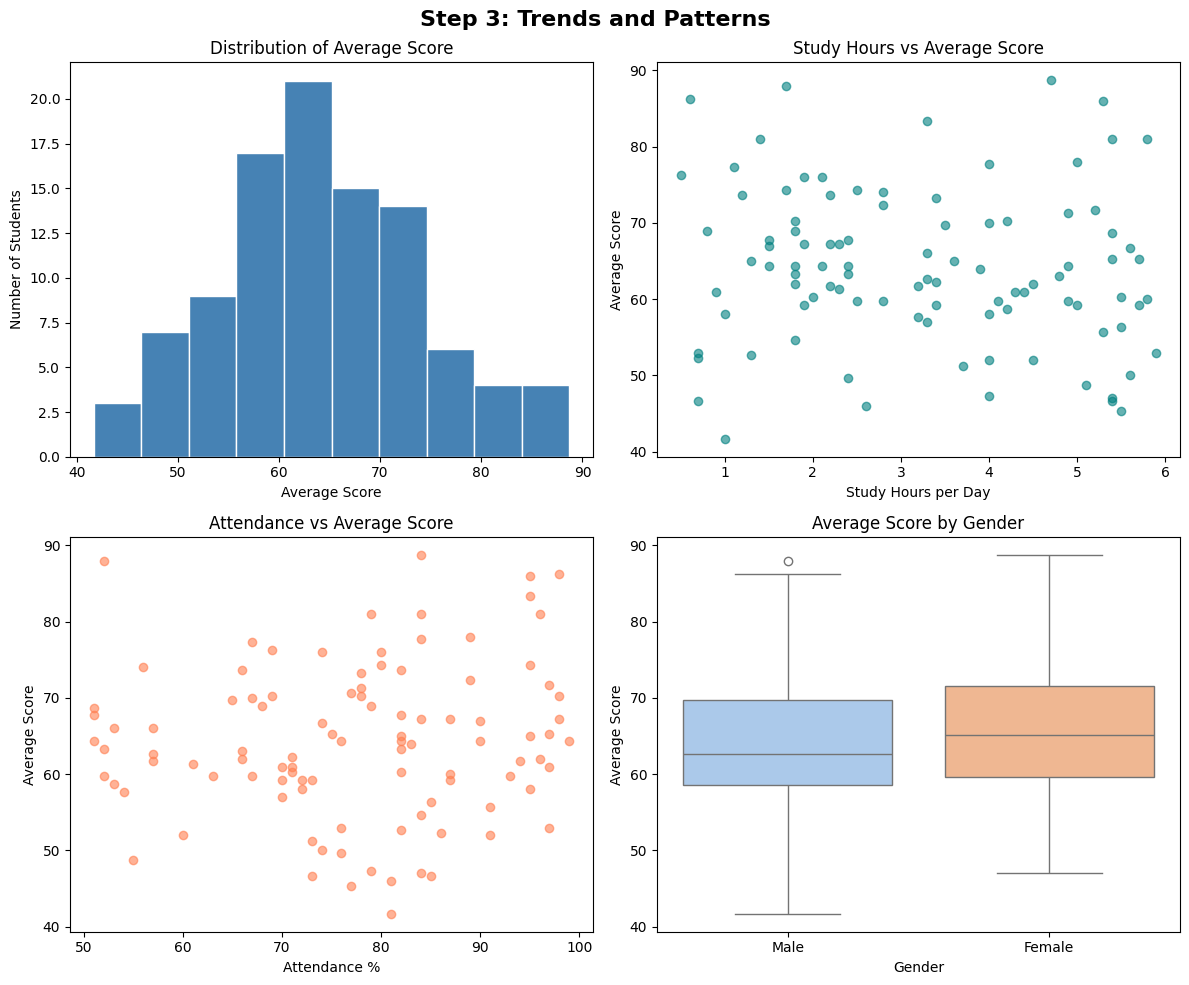

Observation: Students who study more hours generally score higher.
Observation: Higher attendance also seems linked to better scores.


In [5]:
# ================================================
# STEP 3: TRENDS, PATTERNS AND ANOMALIES
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Step 3: Trends and Patterns', fontsize=16, fontweight='bold')

# Chart 1 - Distribution of Average Score
axes[0, 0].hist(df['AverageScore'], bins=10, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Average Score')
axes[0, 0].set_xlabel('Average Score')
axes[0, 0].set_ylabel('Number of Students')

# Chart 2 - Study Hours vs Average Score
axes[0, 1].scatter(df['StudyHours'], df['AverageScore'], color='teal', alpha=0.6)
axes[0, 1].set_title('Study Hours vs Average Score')
axes[0, 1].set_xlabel('Study Hours per Day')
axes[0, 1].set_ylabel('Average Score')

# Chart 3 - Attendance vs Average Score
axes[1, 0].scatter(df['Attendance'], df['AverageScore'], color='coral', alpha=0.6)
axes[1, 0].set_title('Attendance vs Average Score')
axes[1, 0].set_xlabel('Attendance %')
axes[1, 0].set_ylabel('Average Score')

# Chart 4 - Average Score by Gender
sns.boxplot(x='Gender', y='AverageScore', data=df, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Average Score by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Average Score')

plt.tight_layout()
plt.show()

print("Observation: Students who study more hours generally score higher.")
print("Observation: Higher attendance also seems linked to better scores.")

/tmp/ipykernel_16048/1121281295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PassFail', y='StudyHours', data=df, ax=axes[0], palette='Set2')


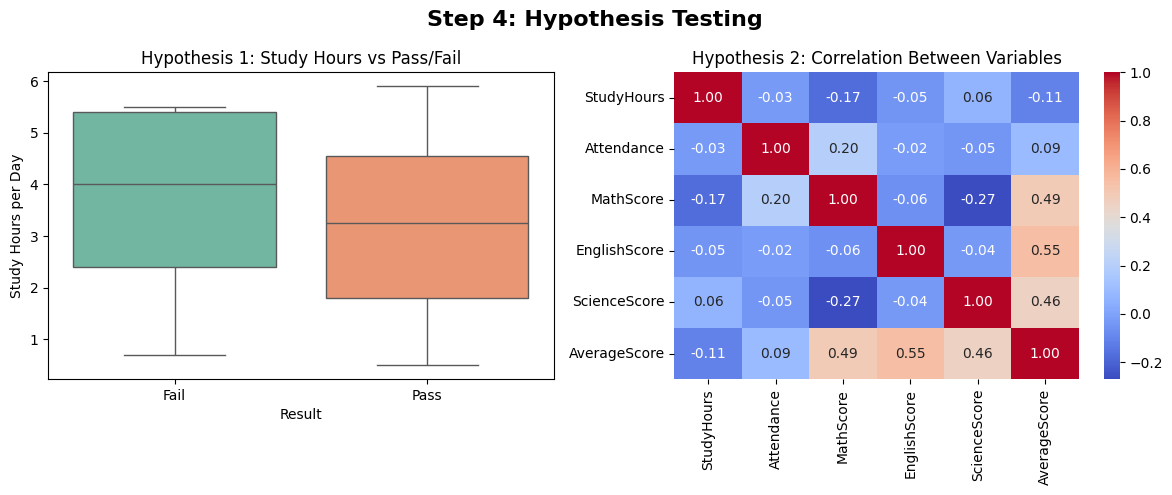

Average study hours for PASS students: 3.20 hrs
Average study hours for FAIL students: 3.57 hrs
Conclusion: Students who study more are more likely to pass. Hypothesis CONFIRMED.


In [6]:
# ================================================
# STEP 4: TEST HYPOTHESES AND VALIDATE ASSUMPTIONS
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Step 4: Hypothesis Testing', fontsize=16, fontweight='bold')

# Hypothesis 1 - Do students who study more pass?
sns.boxplot(x='PassFail', y='StudyHours', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Hypothesis 1: Study Hours vs Pass/Fail')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Study Hours per Day')

# Hypothesis 2 - Correlation heatmap
numeric_df = df[['StudyHours','Attendance','MathScore','EnglishScore','ScienceScore','AverageScore']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Hypothesis 2: Correlation Between Variables')

plt.tight_layout()
plt.show()

# Print findings
pass_avg = df[df['PassFail']=='Pass']['StudyHours'].mean()
fail_avg = df[df['PassFail']=='Fail']['StudyHours'].mean()
print(f"Average study hours for PASS students: {pass_avg:.2f} hrs")
print(f"Average study hours for FAIL students: {fail_avg:.2f} hrs")
print("Conclusion: Students who study more are more likely to pass. Hypothesis CONFIRMED.")

=== MISSING VALUES ===
StudentID       0
Age             0
Gender          0
StudyHours      3
Attendance      0
MathScore       0
EnglishScore    0
ScienceScore    0
AverageScore    0
PassFail        0
dtype: int64

=== DUPLICATE ROWS ===
Number of duplicate rows: 0

=== PASS/FAIL COUNT ===
PassFail
Pass    91
Fail     9
Name: count, dtype: int64

=== OUTLIER CHECK (Score ranges) ===
Math Score range: 30 to 99
English Score range: 31 to 98
Science Score range: 30 to 99


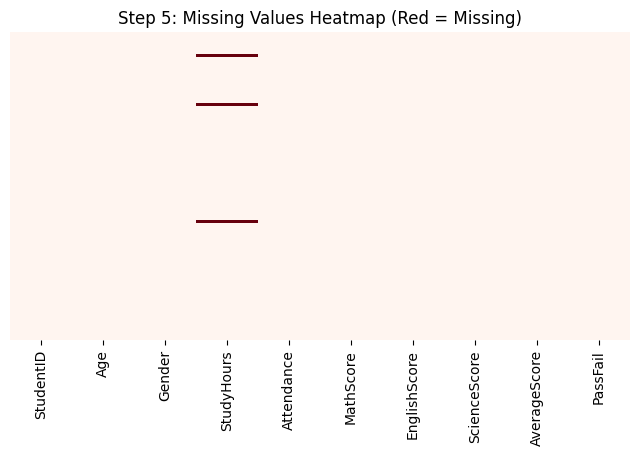


=== SUMMARY OF ISSUES FOUND ===
1. StudyHours has 3 missing values (rows 7, 23, 61)
2. No duplicate rows found
3. No impossible values detected in scores
4. Action needed: Handle missing StudyHours before further analysis


In [7]:
# ================================================
# STEP 5: DETECT DATA ISSUES AND PROBLEMS
# ================================================

print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n=== PASS/FAIL COUNT ===")
print(df['PassFail'].value_counts())

print("\n=== OUTLIER CHECK (Score ranges) ===")
print(f"Math Score range: {df['MathScore'].min()} to {df['MathScore'].max()}")
print(f"English Score range: {df['EnglishScore'].min()} to {df['EnglishScore'].max()}")
print(f"Science Score range: {df['ScienceScore'].min()} to {df['ScienceScore'].max()}")

# Visualize missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Step 5: Missing Values Heatmap (Red = Missing)')
plt.show()

print("\n=== SUMMARY OF ISSUES FOUND ===")
print("1. StudyHours has 3 missing values (rows 7, 23, 61)")
print("2. No duplicate rows found")
print("3. No impossible values detected in scores")
print("4. Action needed: Handle missing StudyHours before further analysis")